In [41]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as pit 
import seaborn as sns 

In [42]:
df = pd.read_csv('kelayakan-pendidikan-indonesia.csv') 


print("Shape:" ,  df.shape)
print("\nClomns :\n" , df.columns)



Shape: (39, 15)

Clomns :
 Index(['Provinsi', 'Sekolah', 'Siswa', 'Mengulang', 'Putus Sekolah',
       'Kepala Sekolah dan Guru(<S1)', 'Kepala Sekolah dan Guru(≥ S1)',
       'Tenaga Kependidikan(SM)', 'Tenaga Kependidikan(>SM)',
       'Rombongan Belajar', 'Ruang kelas(baik)', 'Ruang kelas(rusak ringan)',
       'Ruang kelas(rusak sedang)', 'Ruang kelas(rusak berat)', 'Unnamed: 14'],
      dtype='str')


In [43]:
print("\nInfo :")
print(df.info())


Info :
<class 'pandas.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Provinsi                       39 non-null     str    
 1   Sekolah                        39 non-null     int64  
 2   Siswa                          39 non-null     int64  
 3   Mengulang                      39 non-null     int64  
 4   Putus Sekolah                  39 non-null     int64  
 5   Kepala Sekolah dan Guru(<S1)   39 non-null     int64  
 6   Kepala Sekolah dan Guru(≥ S1)  39 non-null     int64  
 7   Tenaga Kependidikan(SM)        39 non-null     int64  
 8   Tenaga Kependidikan(>SM)       39 non-null     int64  
 9   Rombongan Belajar              39 non-null     int64  
 10  Ruang kelas(baik)              39 non-null     int64  
 11  Ruang kelas(rusak ringan)      39 non-null     int64  
 12  Ruang kelas(rusak sedang)      39 non-null     int64  


In [44]:
print("\nDescribe :")
print(df.describe())


Describe :
            Sekolah         Siswa    Mengulang  Putus Sekolah  \
count     39.000000  3.900000e+01    39.000000      39.000000   
mean    3817.487179  6.170439e+05  2840.820513    1155.051282   
std     4862.821186  8.650352e+05  2312.422413    1167.778659   
min      124.000000  1.778900e+04    56.000000      75.000000   
25%      956.500000  1.431760e+05  1257.500000     466.000000   
50%     2347.000000  3.123520e+05  2049.000000     835.000000   
75%     4326.500000  7.098810e+05  4212.000000    1279.500000   
max    19553.000000  4.487262e+06  9801.000000    5675.000000   

       Kepala Sekolah dan Guru(<S1)  Kepala Sekolah dan Guru(≥ S1)  \
count                     39.000000                      39.000000   
mean                    1311.923077                   40251.846154   
std                     1016.534991                   48430.707661   
min                       76.000000                     450.000000   
25%                      593.000000                 

In [45]:
df = df.drop(columns=["Unnamed: 14"])

In [46]:
print("\nMissing Value :")
print(df.isnull().sum())


Missing Value :
Provinsi                         0
Sekolah                          0
Siswa                            0
Mengulang                        0
Putus Sekolah                    0
Kepala Sekolah dan Guru(<S1)     0
Kepala Sekolah dan Guru(≥ S1)    0
Tenaga Kependidikan(SM)          0
Tenaga Kependidikan(>SM)         0
Rombongan Belajar                0
Ruang kelas(baik)                0
Ruang kelas(rusak ringan)        0
Ruang kelas(rusak sedang)        0
Ruang kelas(rusak berat)         0
dtype: int64


In [47]:
print("\nJumlah Dupicate :")
print(df.duplicated().sum())


Jumlah Dupicate :
0


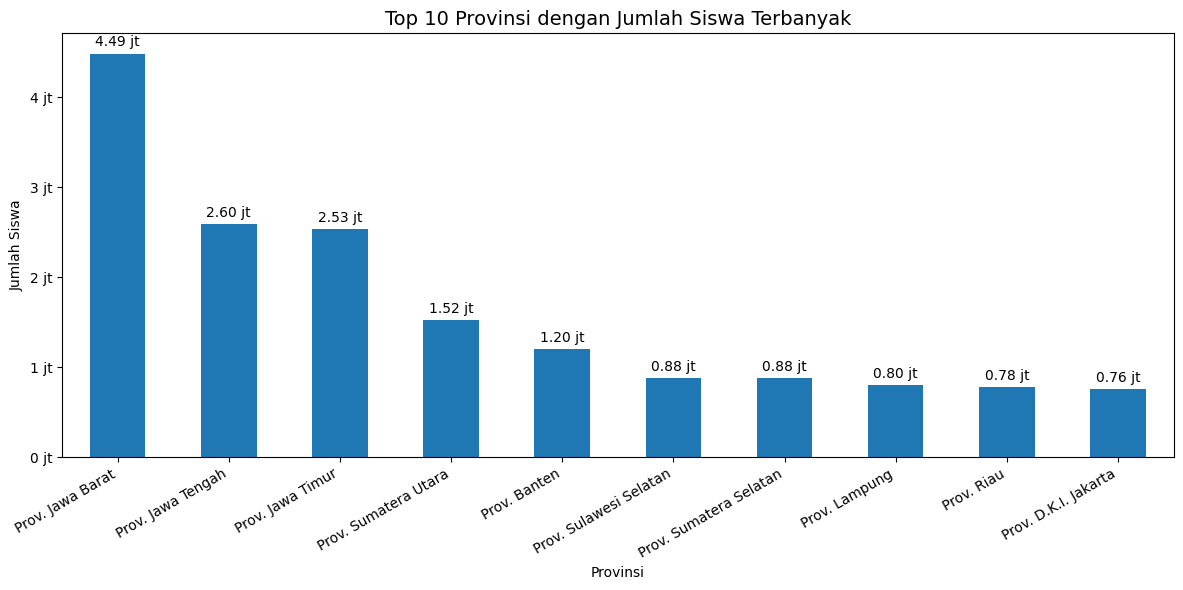

In [48]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Ambil Top 10 provinsi dengan siswa terbanyak
top_siswa = (
    df.groupby('Provinsi')['Siswa']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Buat grafik
plt.figure(figsize=(12, 6))
ax = top_siswa.plot(kind='bar')

# Format angka biar ga ribet (jutaan)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x/1e6)} jt'))

# Tambahin label di atas batang (dibulatkan + jutaan)
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v/1e6:.2f} jt' for v in top_siswa.values],
        padding=3
    )

# Judul & label
plt.title('Top 10 Provinsi dengan Jumlah Siswa Terbanyak', fontsize=14)
plt.xlabel('Provinsi')
plt.ylabel('Jumlah Siswa')

# Biar ga nabrak
plt.xticks(rotation=30, ha='right')

# Layout biar rapi
plt.tight_layout()

plt.show()

In [49]:
import pandas as pd
from sqlalchemy import create_engine

db_user = 'root'
db_password = ''
db_host = '127.0.0.1'
db_name = 'latihan'

connection_string = f'mysql+pymysql://{db_user}:{db_password}@{db_host}/{db_name}'
engine = create_engine(connection_string)

nama_tabel_baru = 'kelayakan-pendidikan-indonesia'

print("Sedang menyimpan DataFrame ke database MySQL...")

try: 

    df.to_sql(nama_tabel_baru, con=engine, if_exists='replace', index=False)
    print(f"Data berhasil disimpan ke tabel '{nama_tabel_baru}' di database '{db_name}'")

except Exception as e:
    print("Terjadi kesalahan saat menyimpan data ke database:", e)


Sedang menyimpan DataFrame ke database MySQL...
Data berhasil disimpan ke tabel 'kelayakan-pendidikan-indonesia' di database 'latihan'
